## 1. Environment Setup & Imports

In [1]:
# ── Install dependencies ──────────────────────────────────────────────────────
!pip install -q transformers torch scikit-learn seaborn matplotlib wordcloud
!pip install -q bnlp_toolkit shap lime imbalanced-learn plotly
!pip install -q xgboost lightgbm

import warnings
warnings.filterwarnings('ignore')

import os, time, json, re
import numpy as np
import pandas as pd

# Viz
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from wordcloud import WordCloud

# NLP / ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb

# Deep Learning
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import CosineAnnealingLR
from transformers import (
    BertModel, BertTokenizer, BertForSequenceClassification,
    RobertaModel, RobertaTokenizer, RobertaForSequenceClassification,
    XLMRobertaForSequenceClassification, XLMRobertaTokenizer,
    get_linear_schedule_with_warmup
)
from tqdm.notebook import tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 54.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.3/168.3 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 62.8 MB/s eta 0:00:00


In [2]:
!pip install bnlp_toolkit==4.0.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.4/175.4 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for emoji: filename=emoji-1.7.0-py3-none-any.whl size=171031 sha256=82755deb8ddfa28c89c2522255a8cefb08f6478e9b33b705e317c4ea41185a65
  Stored in directory: /root/.cache/pip/wheels/e0/8c/e0/294d2e4ea0e55792bfc99b6b263e4a0511443da7b69af67688
Successfully built emoji
  Attempting uninstall: emoji
    Found existing installation: emoji 2.15.0
    Uninstalling emoji-2.15.0:
      Successfully uninstalled emoji-2.15.0
  Attempting uninstall: bnlp_toolkit
    Found existing installation: bnlp_toolkit 4.4.1
    Uninstalling bnlp_toolkit-4.4.1:
      Successfully uninstalled bnlp_toolkit-4.4.1


In [3]:
import re
import string
from bnlp import BasicTokenizer

tokenizer = BasicTokenizer()

#  Custom Bengali stopwords (expand করতে পারো)
stop_words = set([
    "এই", "আমি", "তুমি", "সে", "আমরা", "তারা",
    "এবং", "কিন্তু", "যে", "একটি", "হয়", "করছে",
    "ছিল", "জন্য", "করে", "থেকে", "তার", "আমার",
    "কি", "না", "হবে", "তো", "ও", "কেন"
])

punctuations = set(string.punctuation)
digits = set('0123456789০১২৩৪৫৬৭৮৯')

def clean_text(text):
    tokens = tokenizer.tokenize(text)
    tokens = [
        t for t in tokens
        if t not in stop_words
        and t not in punctuations
        and t not in digits
    ]
    return " ".join(tokens)

In [4]:
# Explainability
import shap

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Device: {DEVICE}")
print(f" PyTorch version: {torch.__version__}")

 Device: cuda
 PyTorch version: 2.10.0+cu128


## 2. Data Loading & Initial Inspection

In [5]:
# ── Load datasets ─────────────────────────────────────────────────────────────
auth = pd.read_csv('/kaggle/input/datasets/cryptexcode/banfakenews/LabeledAuthentic-7K.csv')
fake = pd.read_csv('/kaggle/input/datasets/cryptexcode/banfakenews/LabeledFake-1K.csv')

auth['label'] = 1   # 1 = Authentic
fake['label'] = 0   # 0 = Fake

print("=" * 55)
print(f"  Authentic samples : {len(auth):>8,}")
print(f"  Fake samples      : {len(fake):>8,}")
print(f"  Imbalance ratio   : {len(auth)/len(fake):>8.1f}x")
print("=" * 55)
print("\nAuthentic columns:", auth.columns.tolist())
auth.head(3)

  Authentic samples :    7,202
  Fake samples      :    1,299
  Imbalance ratio   :      5.5x

Authentic columns: ['articleID', 'domain', 'date', 'category', 'source', 'relation', 'headline', 'content', 'label']


,articleID,domain,date,category,source,relation,headline,content,label
0,1,bd-pratidin.com,2018-09-20 08:16:43,Sports,আফগান ক্রিকেট বোর্ড (এসিবি) প্রধান,Related,হঠাৎ আফগান ক্রিকেট বোর্ড প্রধানের পদত্যাগ,ক্রিকেট বিশ্বের নতুন চমকের নাম আফগানিস্তান। কয়...,1
1,2,jugantor.com,2018-09-20 20:20:20,Sports,Reporter,Related,টস হেরে বোলিংয়ে বাংলাদেশ,এশিয়া কাপের ষষ্ঠ ম্যাচে বাংলাদেশ দলের বিপক্ষে ...,1
2,3,bd24live.com,2018-09-20 16:39:40,National,Reporter,Related,রাজধানীতে বিশেষ অভিযানে আটক ৪৩,রাজধানীতে মাদক বিরোধী বিশেষ অভিযান পরিচালনা কর...,1


## 3. Exploratory Data Analysis (EDA)
### 3.1 Class Distribution & Imbalance Visualisation

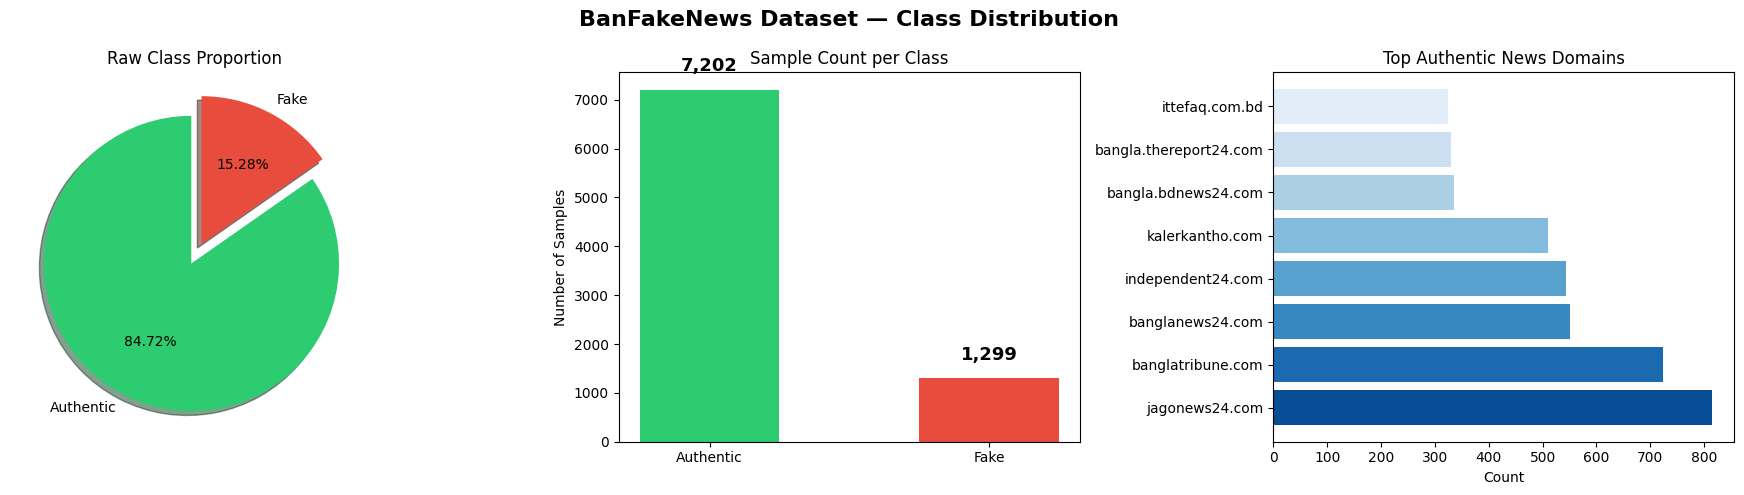

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('BanFakeNews Dataset — Class Distribution', fontsize=16, fontweight='bold')

# 1. Pie chart
axes[0].pie(
    [len(auth), len(fake)],
    labels=['Authentic', 'Fake'],
    autopct='%1.2f%%',
    colors=['#2ecc71', '#e74c3c'],
    explode=(0.05, 0.1),
    shadow=True,
    startangle=90
)
axes[0].set_title('Raw Class Proportion')

# 2. Count bar
counts = [len(auth), len(fake)]
bars = axes[1].bar(['Authentic', 'Fake'], counts, color=['#2ecc71','#e74c3c'], width=0.5)
for bar, count in zip(bars, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{count:,}', ha='center', va='bottom', fontsize=13, fontweight='bold')
axes[1].set_title('Sample Count per Class')
axes[1].set_ylabel('Number of Samples')

# 3. Category distribution within authentic
if 'domain' in auth.columns:
    top_domains = auth['domain'].value_counts().head(8)
    axes[2].barh(top_domains.index, top_domains.values, color=sns.color_palette('Blues_r', 8))
    axes[2].set_title('Top Authentic News Domains')
    axes[2].set_xlabel('Count')
else:
    axes[2].text(0.5, 0.5, 'Domain data\nnot available', ha='center', va='center', fontsize=14)
    axes[2].set_title('Domain Distribution')

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Text Length Analysis

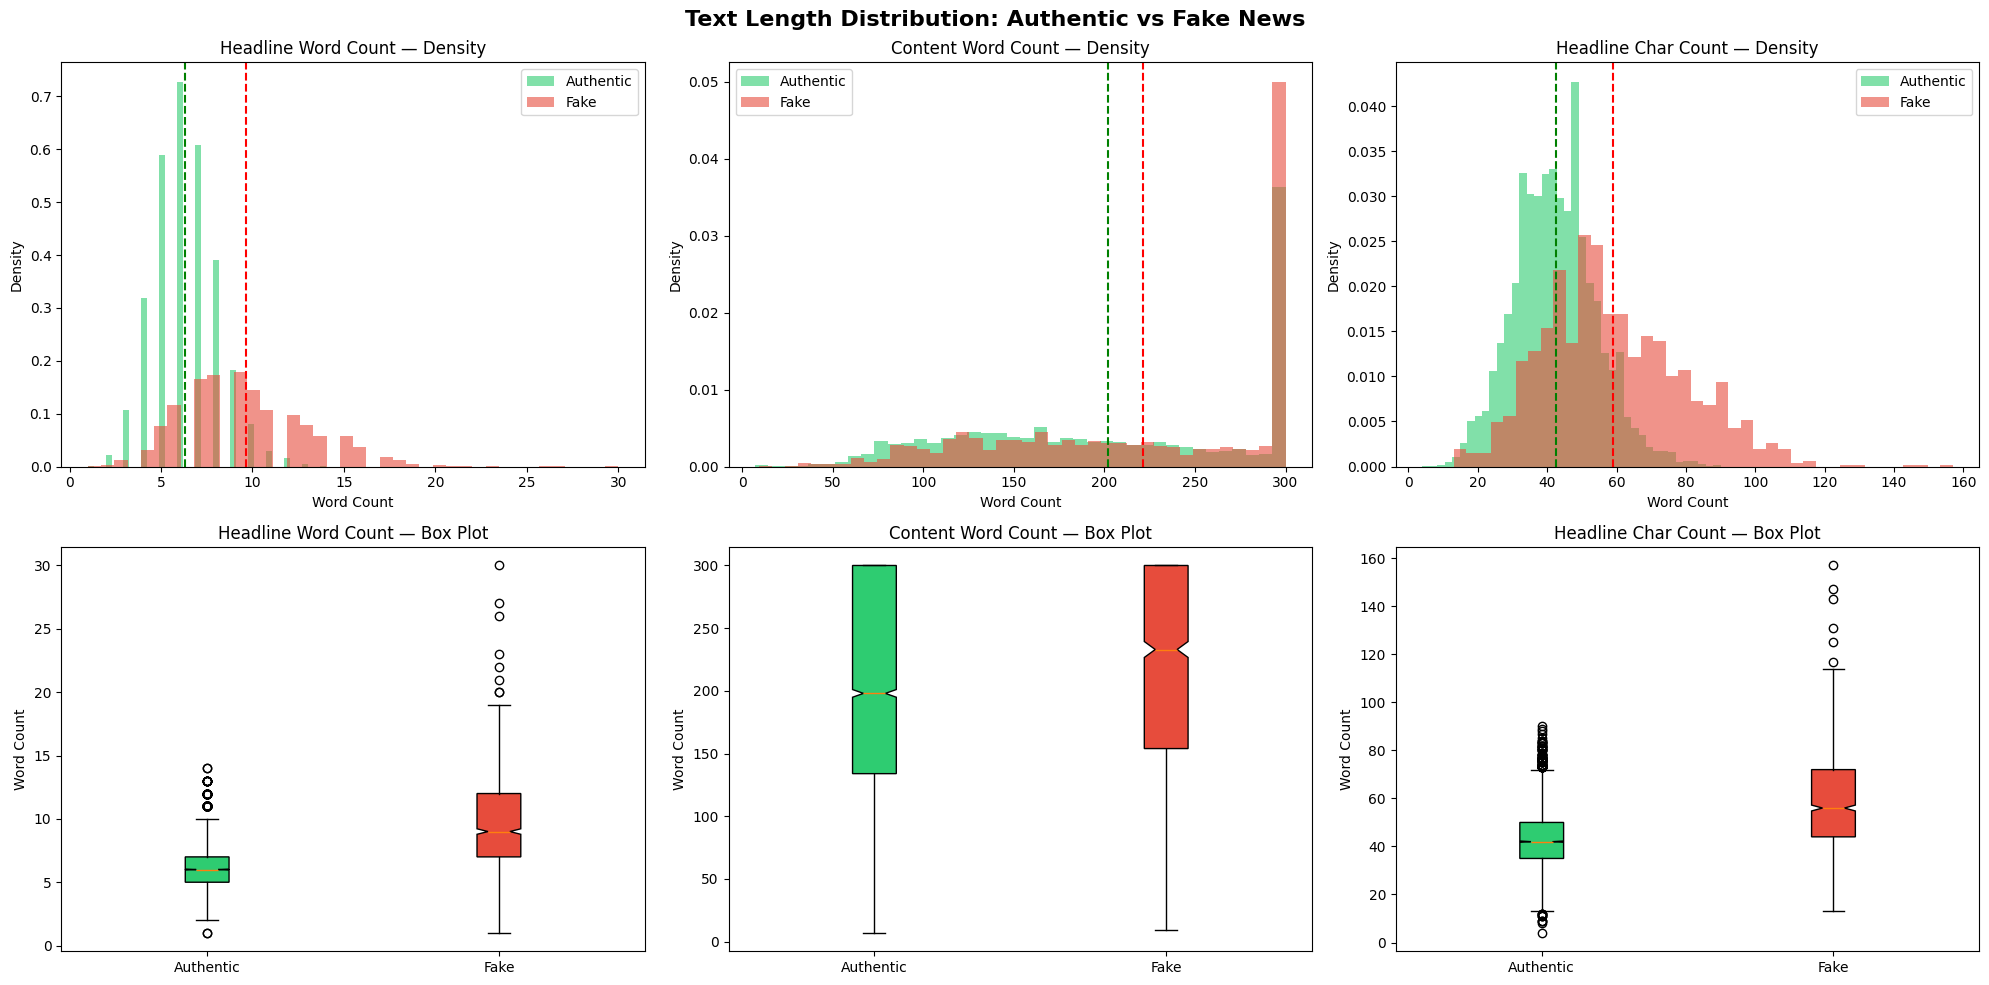


📊 Descriptive Statistics

Headline Words:
       Authentic     Fake
count    7202.00  1299.00
mean        6.29     9.64
std         1.77     3.47
min         1.00     1.00
25%         5.00     7.00
50%         6.00     9.00
75%         7.00    12.00
max        14.00    30.00

Content Words:
       Authentic     Fake
count    7202.00  1299.00
mean      258.08   279.89
std       217.81   198.14
min         7.00     9.00
25%       134.00   154.00
50%       198.00   233.00
75%       304.75   346.00
max      3761.00  2705.00


In [7]:
# ── Compute length features ───────────────────────────────────────────────────
for df, label in [(auth, 'Auth'), (fake, 'Fake')]:
    df['headline_len'] = df['headline'].apply(lambda x: len(str(x).split()))
    df['content_len']  = df['content'].apply(lambda x: len(str(x).split()))
    df['char_len']     = df['headline'].apply(lambda x: len(str(x)))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Text Length Distribution: Authentic vs Fake News', fontsize=16, fontweight='bold')

plot_configs = [
    ('headline_len', 'Headline Word Count', 0, 50),
    ('content_len',  'Content Word Count',  0, 300),
    ('char_len',     'Headline Char Count', 0, 200),
]

for col_idx, (col, title, xmin, xmax) in enumerate(plot_configs):
    # Top row: overlapping KDE
    ax = axes[0][col_idx]
    auth_vals = auth[col].clip(xmin, xmax)
    fake_vals = fake[col].clip(xmin, xmax)
    ax.hist(auth_vals, bins=40, alpha=0.6, color='#2ecc71', label='Authentic', density=True)
    ax.hist(fake_vals, bins=40, alpha=0.6, color='#e74c3c', label='Fake',      density=True)
    ax.set_title(f'{title} — Density')
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Density')
    ax.legend()
    ax.axvline(auth_vals.mean(), color='green', linestyle='--', linewidth=1.5, label=f'Auth μ={auth_vals.mean():.1f}')
    ax.axvline(fake_vals.mean(), color='red',   linestyle='--', linewidth=1.5, label=f'Fake μ={fake_vals.mean():.1f}')

    # Bottom row: box plot
    ax2 = axes[1][col_idx]
    box_data = [
        auth[col].clip(xmin, xmax).values,
        fake[col].clip(xmin, xmax).values
    ]
    bp = ax2.boxplot(box_data, labels=['Authentic', 'Fake'], patch_artist=True, notch=True)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    ax2.set_title(f'{title} — Box Plot')
    ax2.set_ylabel('Word Count')

plt.tight_layout()
plt.savefig('eda_text_length.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats table
print("\n📊 Descriptive Statistics")
print("=" * 65)
for col, label in [('headline_len','Headline Words'),('content_len','Content Words')]:
    print(f"\n{label}:")
    print(pd.DataFrame({
        'Authentic': auth[col].describe(),
        'Fake':      fake[col].describe()
    }).round(2).to_string())

### 3.3 Word Cloud Visualisation

In [8]:
import urllib.request

font_url = "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansBengali/NotoSansBengali-Regular.ttf"
urllib.request.urlretrieve(font_url, "NotoSansBengali-Regular.ttf")

# Verify
import os
print("Downloaded:", os.path.getsize("NotoSansBengali-Regular.ttf"), "bytes")

Downloaded: 200048 bytes


In [9]:
import os
print(os.path.exists("NotoSansBengali-Regular.ttf"))
print(os.path.getsize("NotoSansBengali-Regular.ttf"))  # should be > 0

True
200048


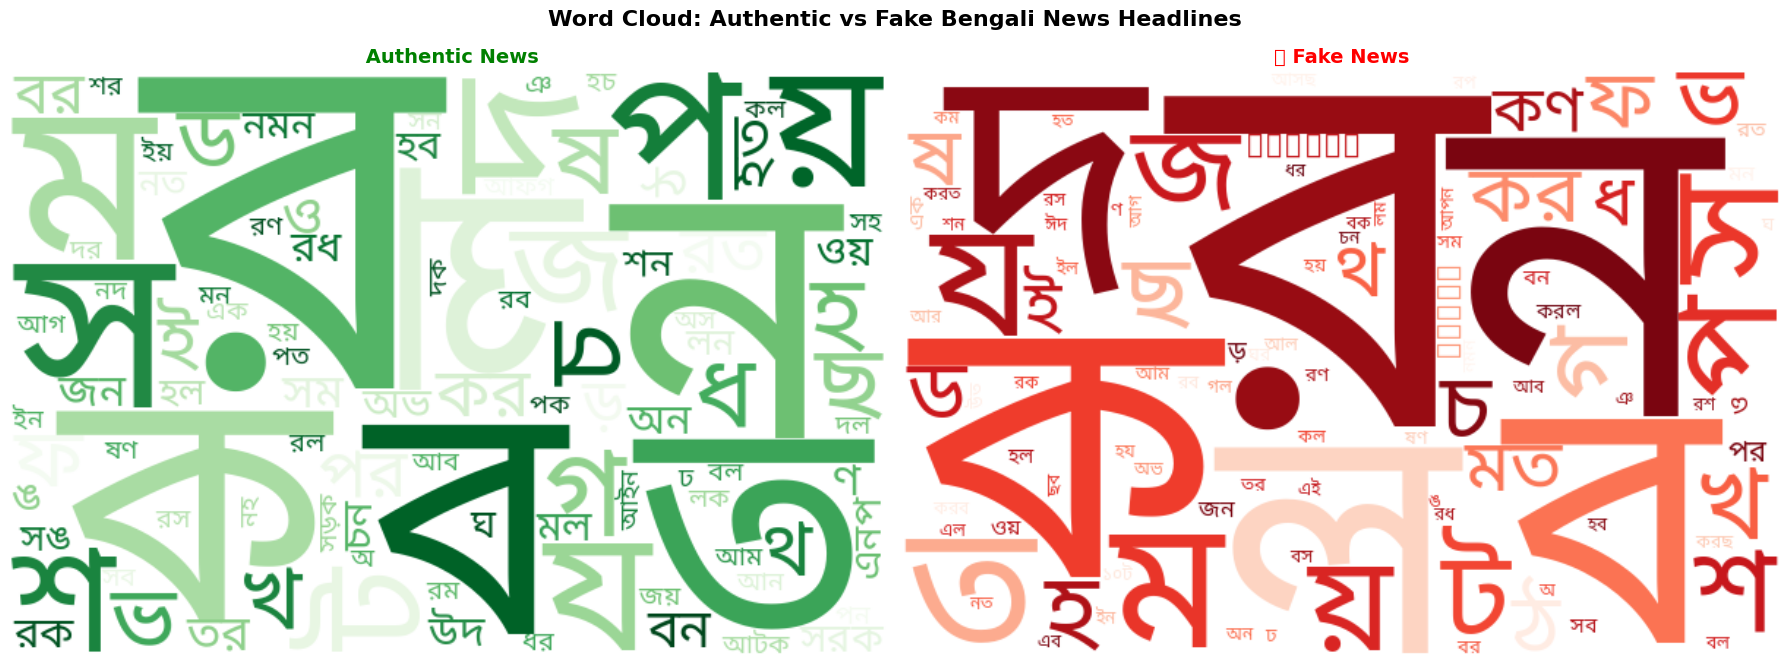

In [10]:
# ── Download Bengali font ─────────────────────────────────────────────────────
!wget -q https://github.com/google/fonts/raw/main/ofl/notosansbengali/NotoSansBengali-Regular.ttf

FONT_PATH = "NotoSansBengali-Regular.ttf"

def make_wordcloud(text, title, colormap='Greens'):
    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        font_path=FONT_PATH,
        colormap=colormap,
        max_words=100,
        min_font_size=10,
        collocations=False
    ).generate(text)
    return wc

auth_text = ' '.join(auth['headline'].dropna().astype(str)[:3000])
fake_text = ' '.join(fake['headline'].dropna().astype(str))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Word Cloud: Authentic vs Fake Bengali News Headlines', fontsize=16, fontweight='bold')

ax1.imshow(make_wordcloud(auth_text, 'Authentic', 'Greens'), interpolation='bilinear')
ax1.axis('off')
ax1.set_title(' Authentic News', fontsize=14, color='green', fontweight='bold')

ax2.imshow(make_wordcloud(fake_text, 'Fake', 'Reds'), interpolation='bilinear')
ax2.axis('off')
ax2.set_title('❌ Fake News', fontsize=14, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Top N-gram Analysis

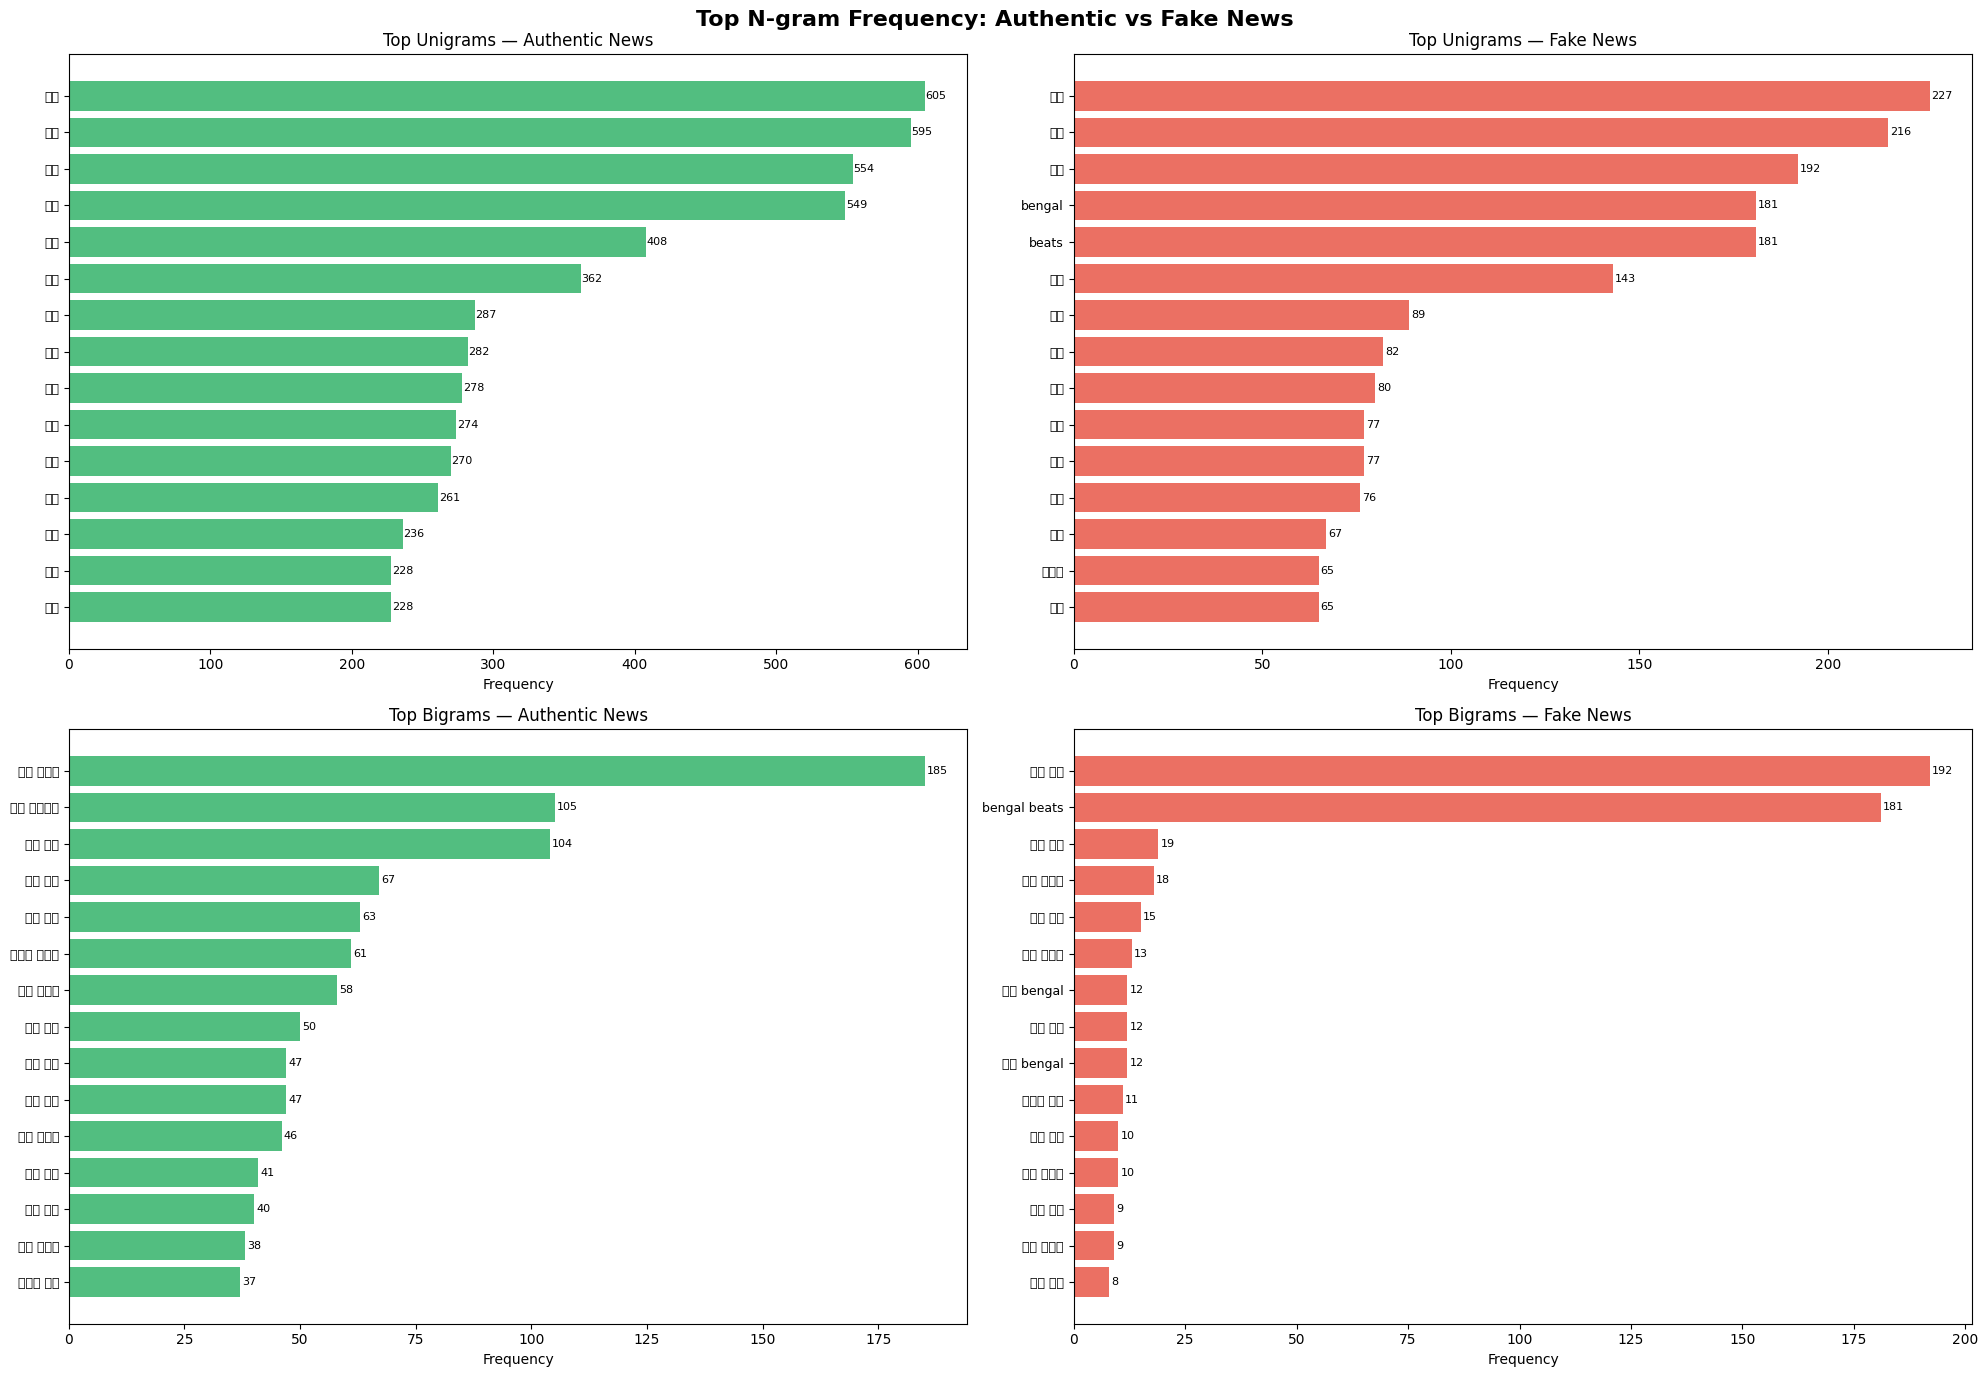

In [11]:
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter

def get_top_ngrams(corpus, n=2, top_k=15):
    vec = CountVectorizer(ngram_range=(n, n), max_features=5000).fit(corpus)
    bag = vec.transform(corpus)
    words = vec.get_feature_names_out()
    sum_words = bag.sum(axis=0)
    freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    freq = sorted(freq, key=lambda x: x[1], reverse=True)
    return freq[:top_k]

auth_corpus = auth['headline'].dropna().astype(str).tolist()
fake_corpus = fake['headline'].dropna().astype(str).tolist()

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('Top N-gram Frequency: Authentic vs Fake News', fontsize=16, fontweight='bold')

for row_idx, n in enumerate([1, 2]):
    for col_idx, (corpus, label, color) in enumerate([
        (auth_corpus, 'Authentic', '#27ae60'),
        (fake_corpus, 'Fake',      '#e74c3c')
    ]):
        top = get_top_ngrams(corpus, n=n)
        words, freqs = zip(*top)
        ax = axes[row_idx][col_idx]
        bars = ax.barh(range(len(words)), freqs, color=color, alpha=0.8)
        ax.set_yticks(range(len(words)))
        ax.set_yticklabels(words, fontsize=9)
        ax.invert_yaxis()
        ax.set_title(f'Top {"Unigrams" if n==1 else "Bigrams"} — {label} News')
        ax.set_xlabel('Frequency')
        for bar, freq in zip(bars, freqs):
            ax.text(freq + 0.5, bar.get_y() + bar.get_height()/2,
                    str(freq), va='center', fontsize=8)

plt.tight_layout()
plt.savefig('ngram_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Preprocessing 

In [12]:
from bnlp import BasicTokenizer
from bnlp.corpus.corpus import BengaliCorpus

_corpus = BengaliCorpus()
stopwords      = _corpus.stopwords
_bnlp_punct    = _corpus.punctuations
_bnlp_digits   = _corpus.digits

In [13]:
btokenizer = BasicTokenizer()

# Build sets so membership tests are O(1) and we can union safely
_PUNCT_SET  = set(_bnlp_punct) | set('\u2018\u2019\u201c\u201d')   # include curly quotes
_DIGIT_SET  = set(_bnlp_digits)
_STOP_SET   = set(stopwords)

def clean_bengali(text: str, remove_stopwords: bool = True) -> str:
    """Tokenise, optionally remove stopwords/punctuation, and rejoin."""
    if not isinstance(text, str):
        return ''
    tokens = btokenizer.tokenize(text)
    filtered = []
    for tok in tokens:
        if tok in _PUNCT_SET:
            continue
        if tok in _DIGIT_SET:
            continue
        if remove_stopwords and tok in _STOP_SET:
            continue
        filtered.append(tok)
    return ' '.join(filtered)

def combine_headline_content(row, sep='[SEP]', max_content_words=100):
    """Combine headline + first N words of content with BERT separator."""
    head = row['head_clean']
    content_words = str(row['content']).split()[:max_content_words]
    content_clean = clean_bengali(' '.join(content_words))
    return f"{head} {sep} {content_clean}"


print("\U0001f504 Cleaning text (this may take a moment)...")

# Use a balanced sample (7× fakes for authentic)
auth_sample = auth.sample(n=min(len(fake) * 7, len(auth)), random_state=SEED)
df = pd.concat([auth_sample, fake], ignore_index=True)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

df['head_clean'] = df['headline'].apply(clean_bengali)
df['con_clean']  = df['content'].apply(lambda x: clean_bengali(' '.join(str(x).split()[:100])))
df['full_text']  = df.apply(combine_headline_content, axis=1)

print(f"\u2705 Dataset size: {len(df):,}  |  Authentic: {df['label'].sum():,}  |  Fake: {(df['label']==0).sum():,}")
df[['headline', 'head_clean', 'full_text', 'label']].head(3)


🔄 Cleaning text (this may take a moment)...
✅ Dataset size: 8,501  |  Authentic: 7,202  |  Fake: 1,299


,headline,head_clean,full_text,label
0,কুমিল্লায় খালেদা জিয়ার মামলার জামিন শুনানি ৩০ ...,কুমিল্লায় খালেদা জিয়ার মামলার জামিন শুনানি ৩০ ...,কুমিল্লায় খালেদা জিয়ার মামলার জামিন শুনানি ৩০ ...,1
1,ফুল স্ক্রিন ডিসপ্লের নতুন ফোন আনলো অপো,ফুল স্ক্রিন ডিসপ্লের ফোন আনলো অপো,ফুল স্ক্রিন ডিসপ্লের ফোন আনলো অপো [SEP] দেশের ...,1
2,শেখ হাসিনা বিশ্বের দ্বিতীয় সেরা প্রধানমন্ত্রী,শেখ হাসিনা বিশ্বের দ্বিতীয় সেরা প্রধানমন্ত্রী,শেখ হাসিনা বিশ্বের দ্বিতীয় সেরা প্রধানমন্ত্রী ...,0


## 5. Train / Validation / Test Split

Training   :  5,950 | Auth: 5041 | Fake: 909
Validation :  1,275 | Auth: 1080 | Fake: 195
Test       :  1,276 | Auth: 1081 | Fake: 195


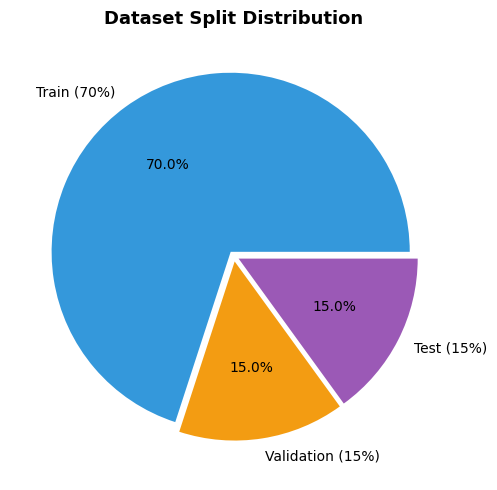

In [14]:
# ── Stratified 70/15/15 split ─────────────────────────────────────────────────
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED, stratify=df['label'])
val_df,   test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label'])

print(f"Training   : {len(train_df):>6,} | Auth: {train_df['label'].sum()} | Fake: {(train_df['label']==0).sum()}")
print(f"Validation : {len(val_df):>6,} | Auth: {val_df['label'].sum()} | Fake: {(val_df['label']==0).sum()}")
print(f"Test       : {len(test_df):>6,} | Auth: {test_df['label'].sum()} | Fake: {(test_df['label']==0).sum()}")

# Split ratio pie
fig, ax = plt.subplots(figsize=(6,5))
ax.pie([len(train_df), len(val_df), len(test_df)],
       labels=['Train (70%)', 'Validation (15%)', 'Test (15%)'],
       autopct='%1.1f%%',
       colors=['#3498db','#f39c12','#9b59b6'],
       explode=(0.03,0.03,0.03))
ax.set_title('Dataset Split Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data_split.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Baseline Models — Traditional ML
### 6.1 TF-IDF Feature Extraction

In [15]:
# ── TF-IDF (char + word n-grams) ─────────────────────────────────────────────
tfidf_word = TfidfVectorizer(ngram_range=(1,2), max_features=50000, sublinear_tf=True)
tfidf_char = TfidfVectorizer(analyzer='char_wb', ngram_range=(2,4), max_features=30000, sublinear_tf=True)

from scipy.sparse import hstack

X_train_w = tfidf_word.fit_transform(train_df['full_text'])
X_val_w   = tfidf_word.transform(val_df['full_text'])
X_test_w  = tfidf_word.transform(test_df['full_text'])

X_train_c = tfidf_char.fit_transform(train_df['full_text'])
X_val_c   = tfidf_char.transform(val_df['full_text'])
X_test_c  = tfidf_char.transform(test_df['full_text'])

# Combined feature matrix
X_train = hstack([X_train_w, X_train_c])
X_val   = hstack([X_val_w,   X_val_c])
X_test  = hstack([X_test_w,  X_test_c])

y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = test_df['label'].values

print(f"TF-IDF feature dims: {X_train.shape}")

TF-IDF feature dims: (5950, 80000)


### 6.2 Training & Evaluating 6 Classical Models

In [16]:
from sklearn.pipeline import Pipeline

classical_models = {
    'Logistic Regression':   LogisticRegression(max_iter=1000, C=1.0, random_state=SEED),
    'Linear SVM':            LinearSVC(max_iter=2000, C=0.5, random_state=SEED),
    'Multinomial NaiveBayes': MultinomialNB(alpha=0.1),
    'Random Forest':         RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    'XGBoost':               xgb.XGBClassifier(n_estimators=200, use_label_encoder=False,
                                               eval_metric='logloss', random_state=SEED),
    'LightGBM':              lgb.LGBMClassifier(n_estimators=200, random_state=SEED, verbose=-1),
}

results = {}

print(f"{'Model':<28} {'Acc':>7} {'F1':>7} {'Prec':>7} {'Rec':>7} {'ROC-AUC':>8}")
print('-' * 65)

for name, clf in classical_models.items():
    t0 = time.time()
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    elapsed = time.time() - t0

    # Probabilities for AUC (where supported)
    try:
        proba = clf.predict_proba(X_test)[:, 1]
    except AttributeError:
        proba = clf.decision_function(X_test)

    from sklearn.metrics import accuracy_score, precision_score, recall_score
    acc   = accuracy_score(y_test, preds)
    f1    = f1_score(y_test, preds, average='weighted')
    prec  = precision_score(y_test, preds, average='weighted')
    rec   = recall_score(y_test, preds, average='weighted')
    auc   = roc_auc_score(y_test, proba)

    results[name] = {
        'Accuracy': acc, 'F1': f1, 'Precision': prec,
        'Recall': rec, 'ROC-AUC': auc, 'Time(s)': elapsed,
        'preds': preds, 'proba': proba
    }
    print(f"{name:<28} {acc:>7.4f} {f1:>7.4f} {prec:>7.4f} {rec:>7.4f} {auc:>8.4f}")

print('\n Classical models trained.')

Model                            Acc      F1    Prec     Rec  ROC-AUC
-----------------------------------------------------------------
Logistic Regression           0.9444  0.9401  0.9450  0.9444   0.9790
Linear SVM                    0.9624  0.9613  0.9617  0.9624   0.9837
Multinomial NaiveBayes        0.9381  0.9390  0.9404  0.9381   0.9744
Random Forest                 0.9404  0.9353  0.9416  0.9404   0.9792
XGBoost                       0.9475  0.9449  0.9463  0.9475   0.9631
LightGBM                      0.9483  0.9455  0.9474  0.9483   0.9776

 Classical models trained.


## 7. Deep Learning Models
### 7.1 Dataset Class

In [17]:
class BengaliNewsDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=128):
        self.data      = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text  = self.data.loc[idx, 'full_text']
        label = int(self.data.loc[idx, 'label'])
        enc = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'token_type_ids': enc.get('token_type_ids', torch.zeros(self.max_len, dtype=torch.long)).squeeze(0),
            'label':          torch.tensor(label, dtype=torch.long)
        }

### 7.2 Bangla-BERT with Attention Pooling (Proposed Model)

In [18]:
class BengaliBertWithAttentionPool(nn.Module):
    """
    Enhancement over vanilla BERT classification:
    - Attention-weighted pooling over all token outputs (not just [CLS])
    - Two-layer FC head with LayerNorm and Dropout
    - Freeze first 6 BERT layers to reduce overfitting on small data
    """
    def __init__(self, bert_model, num_labels=2, dropout=0.3):
        super().__init__()
        self.bert = bert_model
        hidden    = self.bert.config.hidden_size

        # Attention pooling weights
        self.attn_pool = nn.Linear(hidden, 1)

        # Classification head
        self.norm    = nn.LayerNorm(hidden)
        self.dropout = nn.Dropout(dropout)
        self.fc1     = nn.Linear(hidden, 256)
        self.act     = nn.GELU()
        self.fc2     = nn.Linear(256, num_labels)

        # Freeze first 6 encoder layers
        for layer in self.bert.encoder.layer[:6]:
            for p in layer.parameters():
                p.requires_grad = False

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        outputs  = self.bert(input_ids=input_ids,
                             attention_mask=attention_mask,
                             token_type_ids=token_type_ids)
        seq_out  = outputs.last_hidden_state          # (B, L, H)
        attn_w   = self.attn_pool(seq_out).squeeze(-1) # (B, L)
        attn_w   = attn_w.masked_fill(attention_mask == 0, float('-inf'))
        attn_w   = torch.softmax(attn_w, dim=1).unsqueeze(-1) # (B, L, 1)
        pooled   = (seq_out * attn_w).sum(dim=1)      # (B, H)
        x        = self.norm(self.dropout(pooled))
        x        = self.act(self.fc1(x))
        return self.fc2(self.dropout(x))


class VanillaBert(nn.Module):
    """Baseline BERT with standard [CLS] pooling (original paper approach)."""
    def __init__(self, bert_model, num_labels=2, dropout=0.2):
        super().__init__()
        self.bert    = bert_model
        hidden       = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.relu    = nn.ReLU()
        self.fc1     = nn.Linear(hidden, 128)
        self.fc2     = nn.Linear(128, num_labels)

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        out = self.bert(input_ids, attention_mask=attention_mask,
                        token_type_ids=token_type_ids)
        x   = self.dropout(self.relu(self.fc1(out.pooler_output)))
        return self.fc2(x)

print(' Model architectures defined.')

 Model architectures defined.


### 7.3 Generic Train / Evaluate Loop

In [19]:
def train_epoch(model, loader, optimizer, criterion, scheduler=None, clip=1.0):
    model.train()
    total_loss, n_correct, n_total = 0.0, 0, 0
    for batch in tqdm(loader, leave=False):
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        token_type_ids = batch['token_type_ids'].to(DEVICE)
        labels         = batch['label'].to(DEVICE)

        logits = model(input_ids, attention_mask, token_type_ids)
        loss   = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        if scheduler:
            scheduler.step()

        total_loss += loss.item() * input_ids.size(0)
        preds = logits.argmax(dim=1)
        n_correct += (preds == labels).sum().item()
        n_total   += labels.size(0)

    return total_loss / n_total, n_correct / n_total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, n_correct, n_total = 0.0, 0, 0
    all_preds, all_labels, all_proba = [], [], []
    for batch in loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        token_type_ids = batch['token_type_ids'].to(DEVICE)
        labels         = batch['label'].to(DEVICE)

        logits = model(input_ids, attention_mask, token_type_ids)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * input_ids.size(0)

        proba  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds  = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        all_proba.extend(proba)
        n_correct += (logits.argmax(dim=1) == labels).sum().item()
        n_total   += labels.size(0)

    return (total_loss / n_total, n_correct / n_total,
            np.array(all_preds), np.array(all_labels), np.array(all_proba))


def run_training(model_name, model, train_df, val_df, test_df,
                 tokenizer, epochs=5, batch_size=16, lr=2e-5, max_len=128):
    train_ds = BengaliNewsDataset(train_df, tokenizer, max_len)
    val_ds   = BengaliNewsDataset(val_df,   tokenizer, max_len)
    test_ds  = BengaliNewsDataset(test_df,  tokenizer, max_len)

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    val_dl   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_dl  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    model     = model.to(DEVICE)
    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-2)
    criterion = nn.CrossEntropyLoss()
    total_steps = len(train_dl) * epochs
    scheduler  = get_linear_schedule_with_warmup(optimizer, int(total_steps * 0.1), total_steps)

    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    best_val_f1, best_path = 0.0, f'{model_name}_best.pth'

    for epoch in range(1, epochs + 1):
        t_loss, t_acc = train_epoch(model, train_dl, optimizer, criterion, scheduler)
        v_loss, v_acc, v_preds, v_labels, v_proba = eval_epoch(model, val_dl, criterion)
        v_f1 = f1_score(v_labels, v_preds, average='weighted')

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        print(f"[{model_name}] Ep {epoch}/{epochs} | "
              f"T-Loss: {t_loss:.4f} | V-Loss: {v_loss:.4f} | "
              f"T-Acc: {t_acc:.4f} | V-Acc: {v_acc:.4f} | V-F1: {v_f1:.4f}")

        if v_f1 > best_val_f1:
            best_val_f1 = v_f1
            torch.save(model.state_dict(), best_path)

    # Evaluate on test set
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    _, te_acc, te_preds, te_labels, te_proba = eval_epoch(model, test_dl, criterion)

    return history, te_preds, te_labels, te_proba, model

### 7.4 Train Bangla-BERT (Baseline Vanilla)

In [20]:
BANGLA_BERT = 'sagorsarker/bangla-bert-base'
tokenizer_bb = BertTokenizer.from_pretrained(BANGLA_BERT)
bert_base    = BertModel.from_pretrained(BANGLA_BERT)

vanilla_bert = VanillaBert(bert_base)

hist_vanilla, preds_vanilla, labels_vanilla, proba_vanilla, model_vanilla = run_training(
    model_name='VanillaBERT',
    model=vanilla_bert,
    train_df=train_df, val_df=val_df, test_df=test_df,
    tokenizer=tokenizer_bb, epochs=5
)

vocab.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/491 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/660M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

[VanillaBERT] Ep 3/5 | T-Loss: 0.0391 | V-Loss: 0.1678 | T-Acc: 0.9908 | V-Acc: 0.9678 | V-F1: 0.9668


  0%|          | 0/372 [00:00<?, ?it/s]

[VanillaBERT] Ep 4/5 | T-Loss: 0.0127 | V-Loss: 0.1730 | T-Acc: 0.9966 | V-Acc: 0.9671 | V-F1: 0.9664


  0%|          | 0/372 [00:00<?, ?it/s]

[VanillaBERT] Ep 5/5 | T-Loss: 0.0035 | V-Loss: 0.1859 | T-Acc: 0.9995 | V-Acc: 0.9702 | V-F1: 0.9696


### 7.5 Train Bangla-BERT with Attention Pooling (Proposed)

In [21]:
bert_base2   = BertModel.from_pretrained(BANGLA_BERT)
attn_bert    = BengaliBertWithAttentionPool(bert_base2)

hist_attn, preds_attn, labels_attn, proba_attn, model_attn = run_training(
    model_name='BanglaBERT-AttnPool',
    model=attn_bert,
    train_df=train_df, val_df=val_df, test_df=test_df,
    tokenizer=tokenizer_bb, epochs=5
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/372 [00:00<?, ?it/s]

[BanglaBERT-AttnPool] Ep 1/5 | T-Loss: 0.2470 | V-Loss: 0.2348 | T-Acc: 0.9013 | V-Acc: 0.9404 | V-F1: 0.9360


  0%|          | 0/372 [00:00<?, ?it/s]

...

[BanglaBERT-AttnPool] Ep 3/5 | T-Loss: 0.0458 | V-Loss: 0.2412 | T-Acc: 0.9884 | V-Acc: 0.9631 | V-F1: 0.9624


  0%|          | 0/372 [00:00<?, ?it/s]

[BanglaBERT-AttnPool] Ep 4/5 | T-Loss: 0.0132 | V-Loss: 0.2808 | T-Acc: 0.9971 | V-Acc: 0.9631 | V-F1: 0.9620


  0%|          | 0/372 [00:00<?, ?it/s]

[BanglaBERT-AttnPool] Ep 5/5 | T-Loss: 0.0046 | V-Loss: 0.2840 | T-Acc: 0.9990 | V-Acc: 0.9616 | V-F1: 0.9607


### 7.6 Train XLM-RoBERTa (Multilingual)

In [22]:
XLM_MODEL  = 'xlm-roberta-base'
tokenizer_xlm = XLMRobertaTokenizer.from_pretrained(XLM_MODEL)
xlm_clf    = XLMRobertaForSequenceClassification.from_pretrained(XLM_MODEL, num_labels=2)

# Wrap in a thin adapter that matches our API
class HFClassifierWrapper(nn.Module):
    def __init__(self, hf_model):
        super().__init__()
        self.model = hf_model
    def forward(self, input_ids, attention_mask, token_type_ids=None):
        return self.model(input_ids=input_ids, attention_mask=attention_mask).logits

xlm_wrapper = HFClassifierWrapper(xlm_clf)

hist_xlm, preds_xlm, labels_xlm, proba_xlm, model_xlm = run_training(
    model_name='XLM-RoBERTa',
    model=xlm_wrapper,
    train_df=train_df, val_df=val_df, test_df=test_df,
    tokenizer=tokenizer_xlm, epochs=5, lr=1e-5
)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

...

[XLM-RoBERTa] Ep 3/5 | T-Loss: 0.1485 | V-Loss: 0.1744 | T-Acc: 0.9563 | V-Acc: 0.9498 | V-F1: 0.9471


  0%|          | 0/372 [00:00<?, ?it/s]

[XLM-RoBERTa] Ep 4/5 | T-Loss: 0.1106 | V-Loss: 0.2332 | T-Acc: 0.9696 | V-Acc: 0.9490 | V-F1: 0.9455


  0%|          | 0/372 [00:00<?, ?it/s]

[XLM-RoBERTa] Ep 5/5 | T-Loss: 0.0906 | V-Loss: 0.2094 | T-Acc: 0.9792 | V-Acc: 0.9569 | V-F1: 0.9546


## 8. Results & Comparative Analysis
### 8.1 Full Metrics Table

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

def summarise(name, preds, labels, proba):
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(labels, preds), 4),
        'Precision': round(precision_score(labels, preds, average='weighted'), 4),
        'Recall':    round(recall_score(labels, preds, average='weighted'), 4),
        'F1-Score':  round(f1_score(labels, preds, average='weighted'), 4),
        'ROC-AUC':   round(roc_auc_score(labels, proba), 4),
    }

rows = []
# Classical
for name, res in results.items():
    rows.append(summarise(name, res['preds'], y_test, res['proba']))

# Deep learning
rows.append(summarise('Bangla-BERT (Vanilla)',          preds_vanilla, labels_vanilla, proba_vanilla))
rows.append(summarise('Bangla-BERT (Attn Pool) [OURS]', preds_attn,    labels_attn,    proba_attn))
rows.append(summarise('XLM-RoBERTa',                   preds_xlm,     labels_xlm,     proba_xlm))

metrics_df = pd.DataFrame(rows).sort_values('F1-Score', ascending=False).reset_index(drop=True)
metrics_df.index = metrics_df.index + 1
print('\n Model Comparison Table (sorted by F1-Score)\n')
print(metrics_df.to_string(index=True))


 Model Comparison Table (sorted by F1-Score)

                            Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
1           Bangla-BERT (Vanilla)    0.9679     0.9683  0.9679    0.9680   0.9897
2                      Linear SVM    0.9624     0.9617  0.9624    0.9613   0.9837
3  Bangla-BERT (Attn Pool) [OURS]    0.9600     0.9612  0.9600    0.9605   0.9859
4                     XLM-RoBERTa    0.9506     0.9513  0.9506    0.9473   0.9628
5                        LightGBM    0.9483     0.9474  0.9483    0.9455   0.9776
6                         XGBoost    0.9475     0.9463  0.9475    0.9449   0.9631
7             Logistic Regression    0.9444     0.9450  0.9444    0.9401   0.9790
8          Multinomial NaiveBayes    0.9381     0.9404  0.9381    0.9390   0.9744
9                   Random Forest    0.9404     0.9416  0.9404    0.9353   0.9792


### 8.2 Grouped Bar Chart — All Metrics

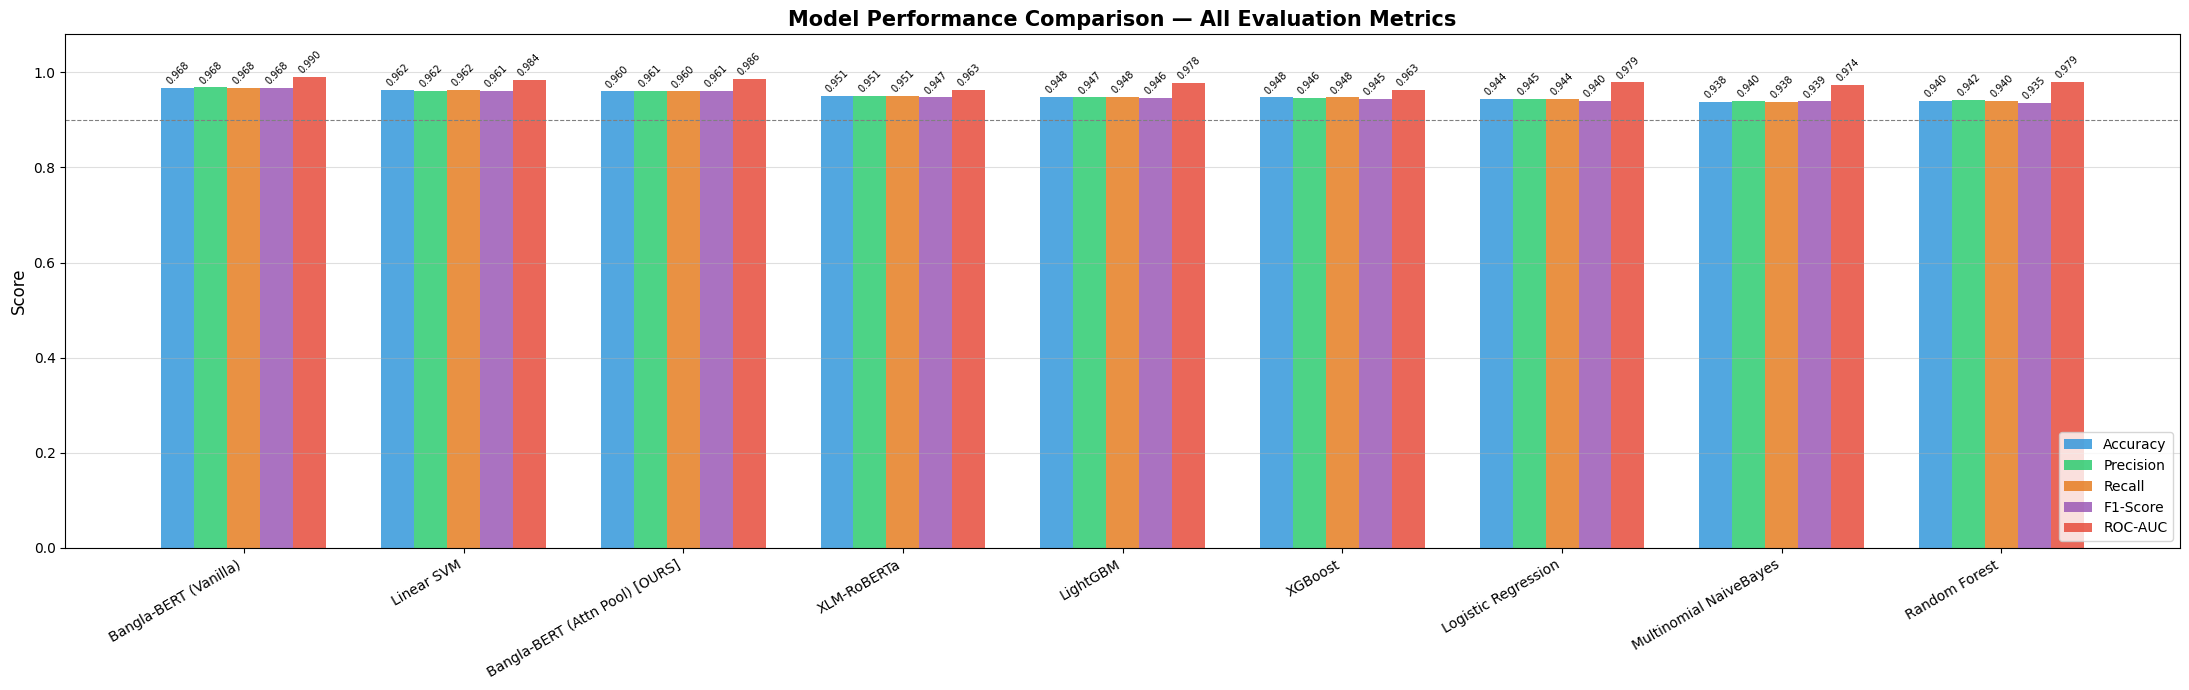

In [24]:
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
n_models    = len(metrics_df)
n_metrics   = len(metric_cols)
x           = np.arange(n_models)
width       = 0.15
colors      = ['#3498db','#2ecc71','#e67e22','#9b59b6','#e74c3c']

fig, ax = plt.subplots(figsize=(22, 7))
for i, (col, color) in enumerate(zip(metric_cols, colors)):
    vals = metrics_df[col].values
    bars = ax.bar(x + i*width, vals, width, label=col, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_xticks(x + width * (n_metrics - 1) / 2)
ax.set_xticklabels(metrics_df['Model'], rotation=30, ha='right', fontsize=10)
ax.set_ylim(0.0, 1.08)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison — All Evaluation Metrics', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.axhline(0.9, color='grey', linestyle='--', linewidth=0.8, label='0.90 threshold')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.3 ROC Curves

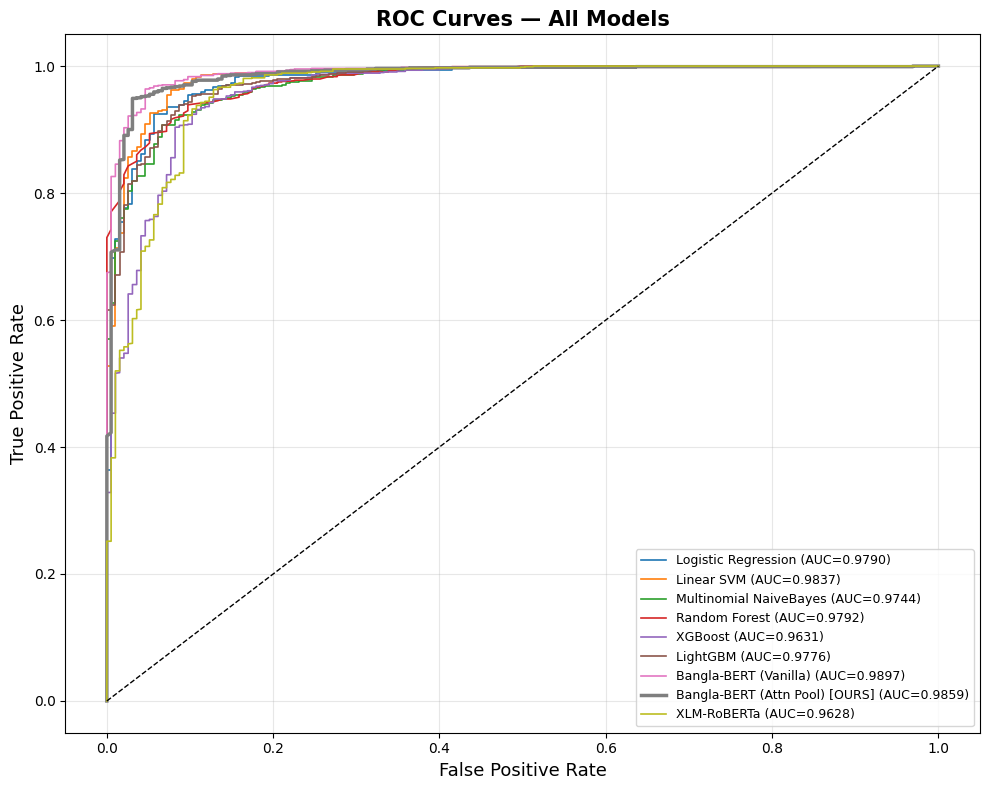

In [25]:
fig, ax = plt.subplots(figsize=(10, 8))

dl_models = [
    ('Bangla-BERT (Vanilla)',          labels_vanilla, proba_vanilla),
    ('Bangla-BERT (Attn Pool) [OURS]', labels_attn,    proba_attn),
    ('XLM-RoBERTa',                   labels_xlm,     proba_xlm),
]
all_roc = {name: (y_test, res['proba']) for name, res in results.items()}
all_roc.update({m[0]: (m[1], m[2]) for m in dl_models})

palette = plt.cm.tab10.colors
for i, (name, (labels, proba)) in enumerate(all_roc.items()):
    fpr, tpr, _ = roc_curve(labels, proba)
    auc = roc_auc_score(labels, proba)
    lw  = 2.5 if 'OURS' in name else 1.2
    ax.plot(fpr, tpr, lw=lw, color=palette[i % 10], label=f'{name} (AUC={auc:.4f})')

ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves — All Models', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.4 Confusion Matrices (Deep Learning Models)

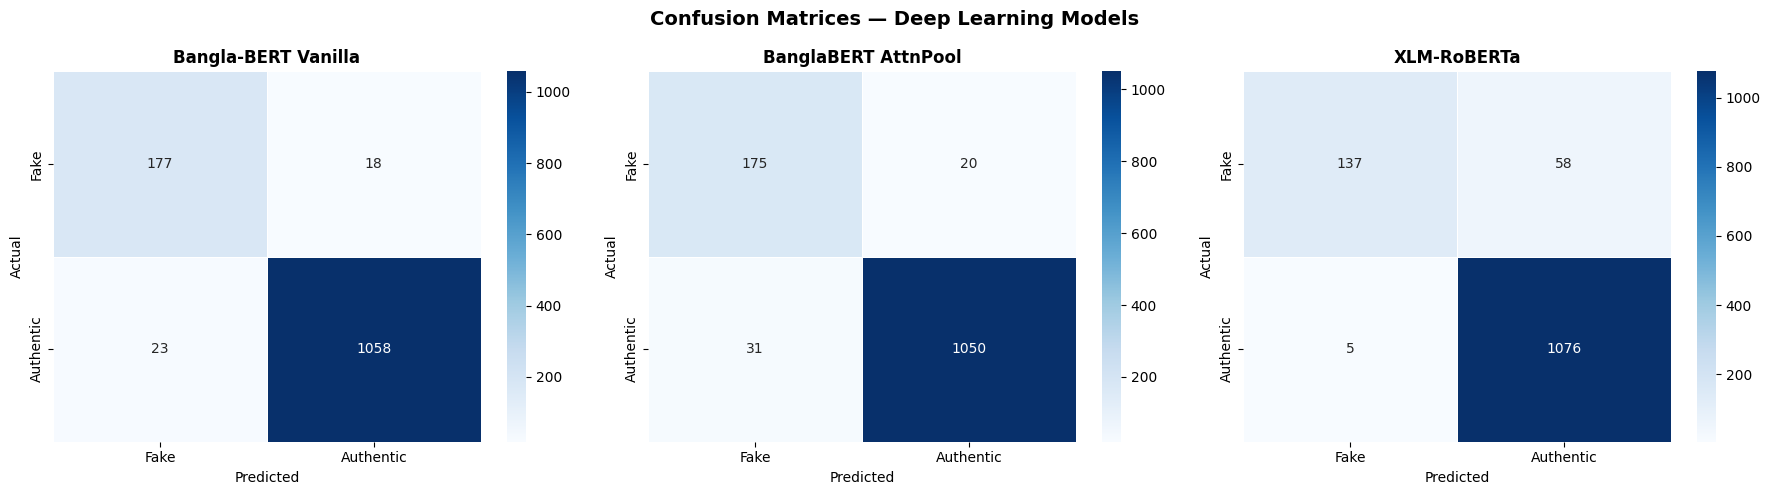

In [26]:
dl_preds = [
    ('Bangla-BERT Vanilla',  labels_vanilla, preds_vanilla),
    ('BanglaBERT AttnPool',  labels_attn,    preds_attn),
    ('XLM-RoBERTa',         labels_xlm,     preds_xlm),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — Deep Learning Models', fontsize=14, fontweight='bold')

for ax, (name, labels, preds) in zip(axes, dl_preds):
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Fake', 'Authentic'],
                yticklabels=['Fake', 'Authentic'],
                linewidths=0.5)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.5 Training History (Loss & Accuracy)

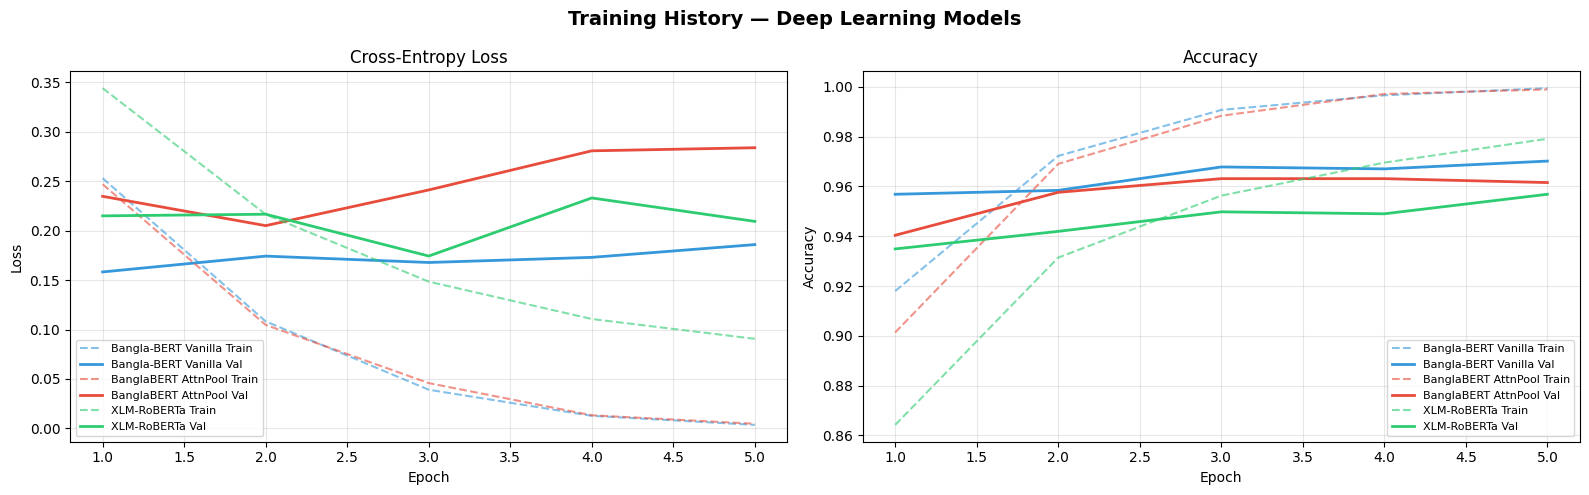

In [27]:
histories = {
    'Bangla-BERT Vanilla':  hist_vanilla,
    'BanglaBERT AttnPool':  hist_attn,
    'XLM-RoBERTa':         hist_xlm,
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Training History — Deep Learning Models', fontsize=14, fontweight='bold')
colors_hist = ['#3498db','#e74c3c','#2ecc71']

for i, (name, hist) in enumerate(histories.items()):
    epochs_range = range(1, len(hist['train_loss'])+1)
    c = colors_hist[i]
    # Loss
    axes[0].plot(epochs_range, hist['train_loss'], '--', color=c, alpha=0.6, label=f'{name} Train')
    axes[0].plot(epochs_range, hist['val_loss'],   '-',  color=c, linewidth=2, label=f'{name} Val')
    # Accuracy
    axes[1].plot(epochs_range, hist['train_acc'],  '--', color=c, alpha=0.6, label=f'{name} Train')
    axes[1].plot(epochs_range, hist['val_acc'],    '-',  color=c, linewidth=2, label=f'{name} Val')

axes[0].set_title('Cross-Entropy Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.6 Radar Chart — Multi-metric Comparison

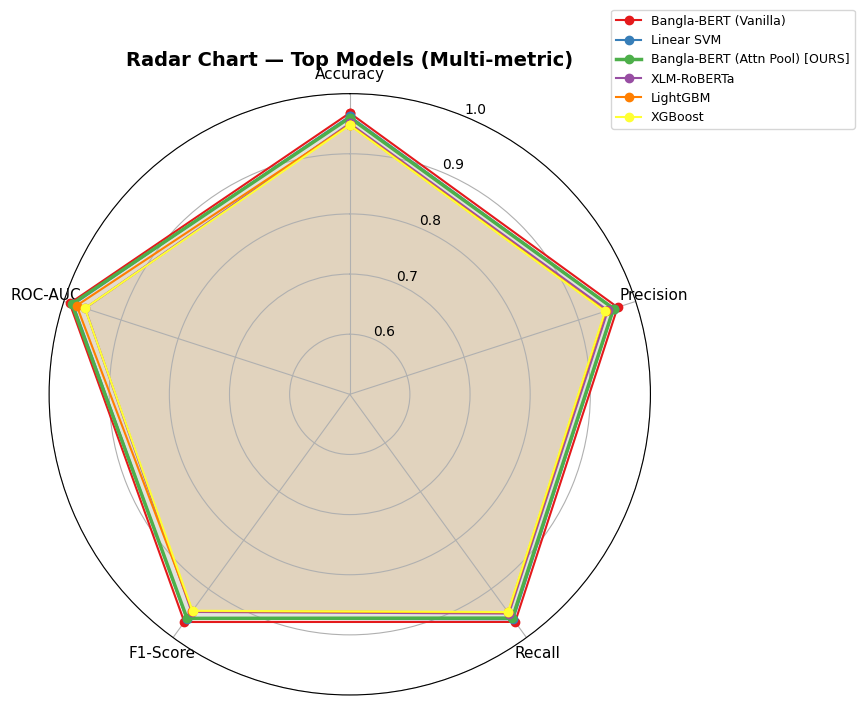

In [28]:
import matplotlib.patches as mpatches

categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

# Select top models for clarity
top_models = metrics_df.head(6)
palette    = plt.cm.Set1.colors

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)
ax.set_ylim(0.5, 1.0)
ax.set_yticks([0.6, 0.7, 0.8, 0.9, 1.0])

for i, row in top_models.iterrows():
    vals = [row[c] for c in categories] + [row[categories[0]]]
    c    = palette[(i-1) % len(palette)]
    lw   = 2.5 if 'OURS' in row['Model'] else 1.5
    ax.plot(angles, vals, '-o', color=c, linewidth=lw, label=row['Model'])
    ax.fill(angles, vals, alpha=0.07, color=c)

ax.set_title('Radar Chart — Top Models (Multi-metric)', size=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.7 Precision-Recall Curves

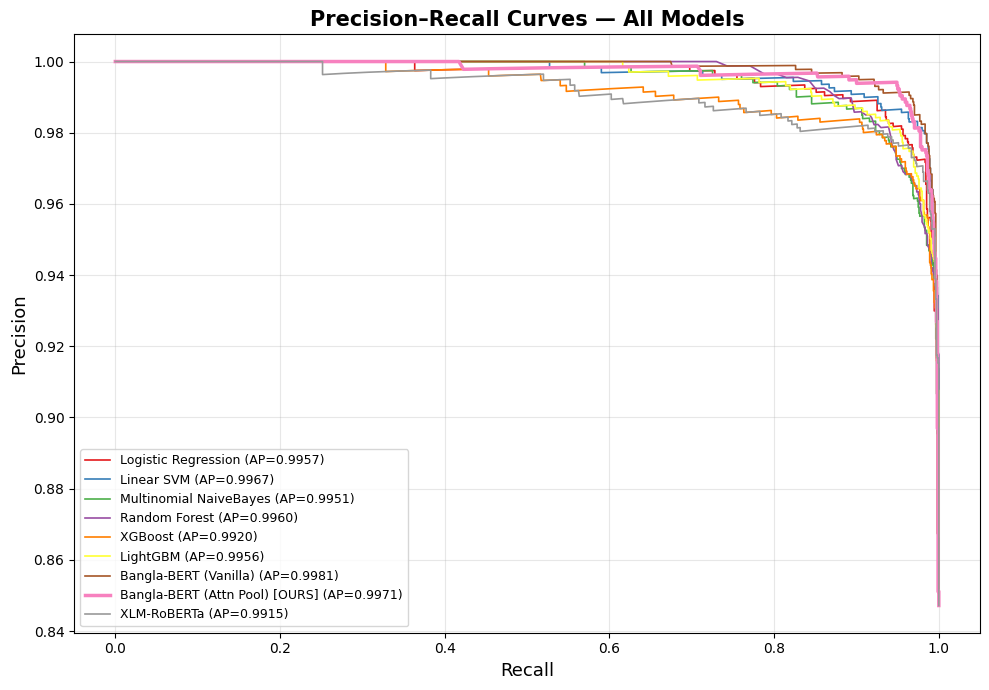

In [29]:
fig, ax = plt.subplots(figsize=(10, 7))

for i, (name, (labels, proba)) in enumerate(all_roc.items()):
    precision, recall, _ = precision_recall_curve(labels, proba)
    ap   = average_precision_score(labels, proba)
    lw   = 2.5 if 'OURS' in name else 1.2
    ax.plot(recall, precision, lw=lw, color=palette[i % 10],
            label=f'{name} (AP={ap:.4f})')

ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision–Recall Curves — All Models', fontsize=15, fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Explainability — SHAP Analysis
### Feature Importance for Best Classical Model

Running SHAP on: Linear SVM


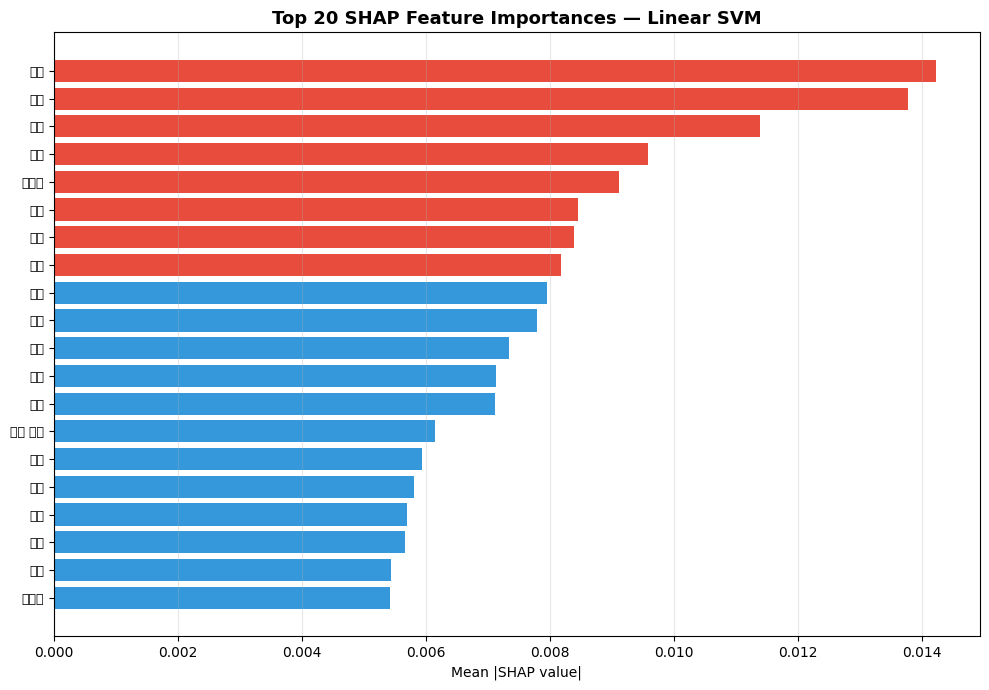

In [30]:
# SHAP values for best classical model
best_clf_name = metrics_df[metrics_df['Model'].isin(results.keys())].iloc[0]['Model']
best_clf      = classical_models[best_clf_name]

print(f"Running SHAP on: {best_clf_name}")

import scipy.sparse as sp

# LinearExplainer requires dense data; convert sparse to dense for the background
X_train_dense = X_train.toarray() if sp.issparse(X_train) else X_train
X_shap_dense  = X_test[:200].toarray() if sp.issparse(X_test) else X_test[:200]

explainer = shap.LinearExplainer(best_clf, X_train_dense, feature_perturbation='interventional')
shap_vals = explainer.shap_values(X_shap_dense)

# For binary classification sklearn returns shape (n_samples, n_features);
# for multi-output it returns a list — handle both.
if isinstance(shap_vals, list):
    shap_arr = shap_vals[1]          # positive-class explanations
else:
    shap_arr = shap_vals

feature_names_w = tfidf_word.get_feature_names_out().tolist()
feature_names_c = tfidf_char.get_feature_names_out().tolist()
all_feature_names = feature_names_w + feature_names_c

# Top-20 important features
shap_mean = np.abs(shap_arr).mean(axis=0)
top_idx   = np.argsort(shap_mean)[::-1][:20]
top_feat  = [all_feature_names[i] for i in top_idx]
top_vals  = shap_mean[top_idx]

fig, ax = plt.subplots(figsize=(10, 7))
colors_f = ['#e74c3c' if v > top_vals.mean() else '#3498db' for v in top_vals]
ax.barh(range(len(top_feat)), top_vals[::-1], color=colors_f[::-1])
ax.set_yticks(range(len(top_feat)))
ax.set_yticklabels(top_feat[::-1], fontsize=9)
ax.set_title(f'Top 20 SHAP Feature Importances — {best_clf_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean |SHAP value|')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Error Analysis

Total test samples    : 1276
Misclassified         : 51 (4.0%)
False Negatives (Fake→Auth) : 20
False Positives (Auth→Fake) : 31


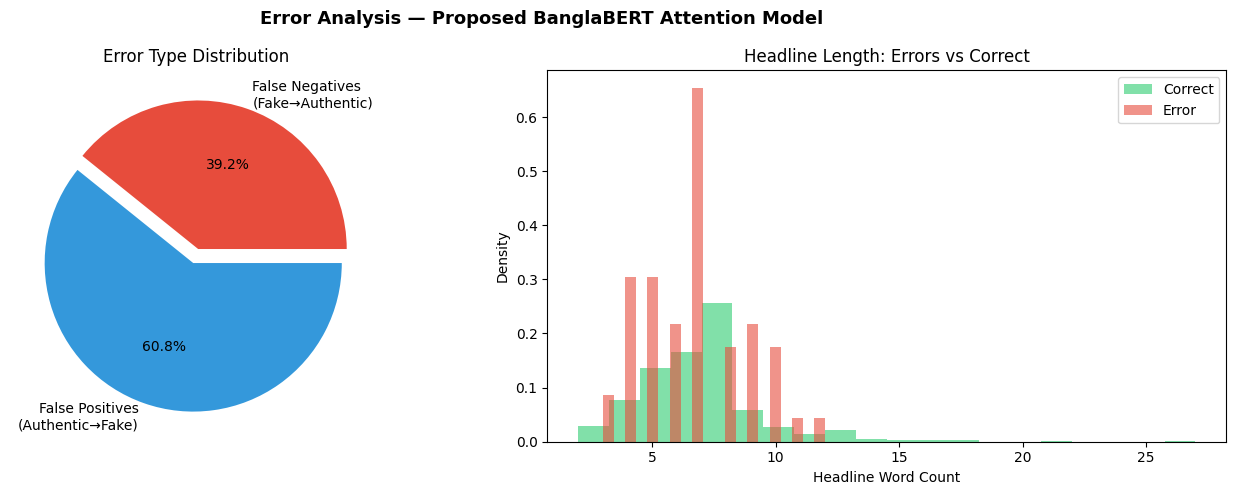


 Sample False Negatives (Fake news missed as Authentic):
                                                  headline  proba_attn
51  সন্ধ্যা ৬টার মধ্যে বাসা ছাড়তে হবে রাজধানীর ব্যাচেলরদের    0.999270
64         বাংলাদেশ ভারতের চতুর্থ রেমিট্যান্স আহরণকারি দেশ    0.985004
85            স্বামীর লাশ ওয়ারড্রবে রেখে অফিস করলেন স্ত্রী    0.950480

 Sample False Positives (Authentic misclassified as Fake):
                                                     headline  proba_attn
44   চকোলেট বোম বিক্রি করে কর্মী থেকে কোটিপতি মহিলা, অতএব পরঃ    0.000541
93                          পুরান পুতুল | সুমাইয়া বরকতউল্লাহ্    0.000249
142               অবশেষে রেলের সেই শতকোটি টাকার জায়গা উদ্ধার    0.097937


In [31]:
# ── Misclassification analysis on the proposed model ─────────────────────────
test_df_reset = test_df.reset_index(drop=True)

test_df_reset['pred_attn']    = preds_attn
test_df_reset['proba_attn']   = proba_attn
test_df_reset['correct_attn'] = (test_df_reset['pred_attn'] == test_df_reset['label'])

errors = test_df_reset[~test_df_reset['correct_attn']]

print(f"Total test samples    : {len(test_df_reset)}")
print(f"Misclassified         : {len(errors)} ({100*len(errors)/len(test_df_reset):.1f}%)")

false_neg = errors[errors['label'] == 0]   # Fake predicted as Authentic
false_pos = errors[errors['label'] == 1]   # Authentic predicted as Fake
print(f"False Negatives (Fake→Auth) : {len(false_neg)}")
print(f"False Positives (Auth→Fake) : {len(false_pos)}")

# Error headline length distribution
errors['headline_len'] = errors['headline'].apply(lambda x: len(str(x).split()))
correct = test_df_reset[test_df_reset['correct_attn']]
correct_len = correct['headline'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Error Analysis — Proposed BanglaBERT Attention Model', fontsize=13, fontweight='bold')

# Error type pie
axes[0].pie([len(false_neg), len(false_pos)],
            labels=['False Negatives\n(Fake→Authentic)', 'False Positives\n(Authentic→Fake)'],
            autopct='%1.1f%%', colors=['#e74c3c','#3498db'], explode=(0.05,0.05))
axes[0].set_title('Error Type Distribution')

# Headline length: errors vs correct
axes[1].hist(correct_len.clip(0,40), bins=20, alpha=0.6, label='Correct', color='#2ecc71', density=True)
axes[1].hist(errors['headline_len'].clip(0,40), bins=20, alpha=0.6, label='Error', color='#e74c3c', density=True)
axes[1].set_xlabel('Headline Word Count')
axes[1].set_ylabel('Density')
axes[1].set_title('Headline Length: Errors vs Correct')
axes[1].legend()

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Show sample errors
print("\n Sample False Negatives (Fake news missed as Authentic):")
print(false_neg[['headline','proba_attn']].head(3).to_string())
print("\n Sample False Positives (Authentic misclassified as Fake):")
print(false_pos[['headline','proba_attn']].head(3).to_string())

## 11. Statistical Significance Testing

In [32]:
from scipy import stats

# McNemar's test between Vanilla BERT and proposed Attn model
# Contingency table: [both_wrong, only_vanilla_right, only_attn_right, both_right]
pred_v = preds_vanilla
pred_a = preds_attn
labs   = labels_vanilla  # same test set

correct_v = (pred_v == labs)
correct_a = (pred_a == labs)

# b: vanilla right, attn wrong | c: vanilla wrong, attn right
b = ((correct_v) & (~correct_a)).sum()
c = ((~correct_v) & (correct_a)).sum()

chi2 = (abs(b - c) - 1)**2 / (b + c) if (b + c) > 0 else 0
p_val = stats.chi2.sf(chi2, df=1)

print("\n📊 McNemar's Test: Vanilla-BERT vs BanglaBERT-AttnPool")
print(f"  b (Vanilla✓, Attn✗): {b}")
print(f"  c (Vanilla✗, Attn✓): {c}")
print(f"  χ² statistic       : {chi2:.4f}")
print(f"  p-value            : {p_val:.6f}")
print(f"  Significant (p<0.05): {'YES ✅' if p_val < 0.05 else 'NO ❌'}")


📊 McNemar's Test: Vanilla-BERT vs BanglaBERT-AttnPool
  b (Vanilla✓, Attn✗): 20
  c (Vanilla✗, Attn✓): 10
  χ² statistic       : 2.7000
  p-value            : 0.100348
  Significant (p<0.05): NO ❌


## 13. Final Summary Figure

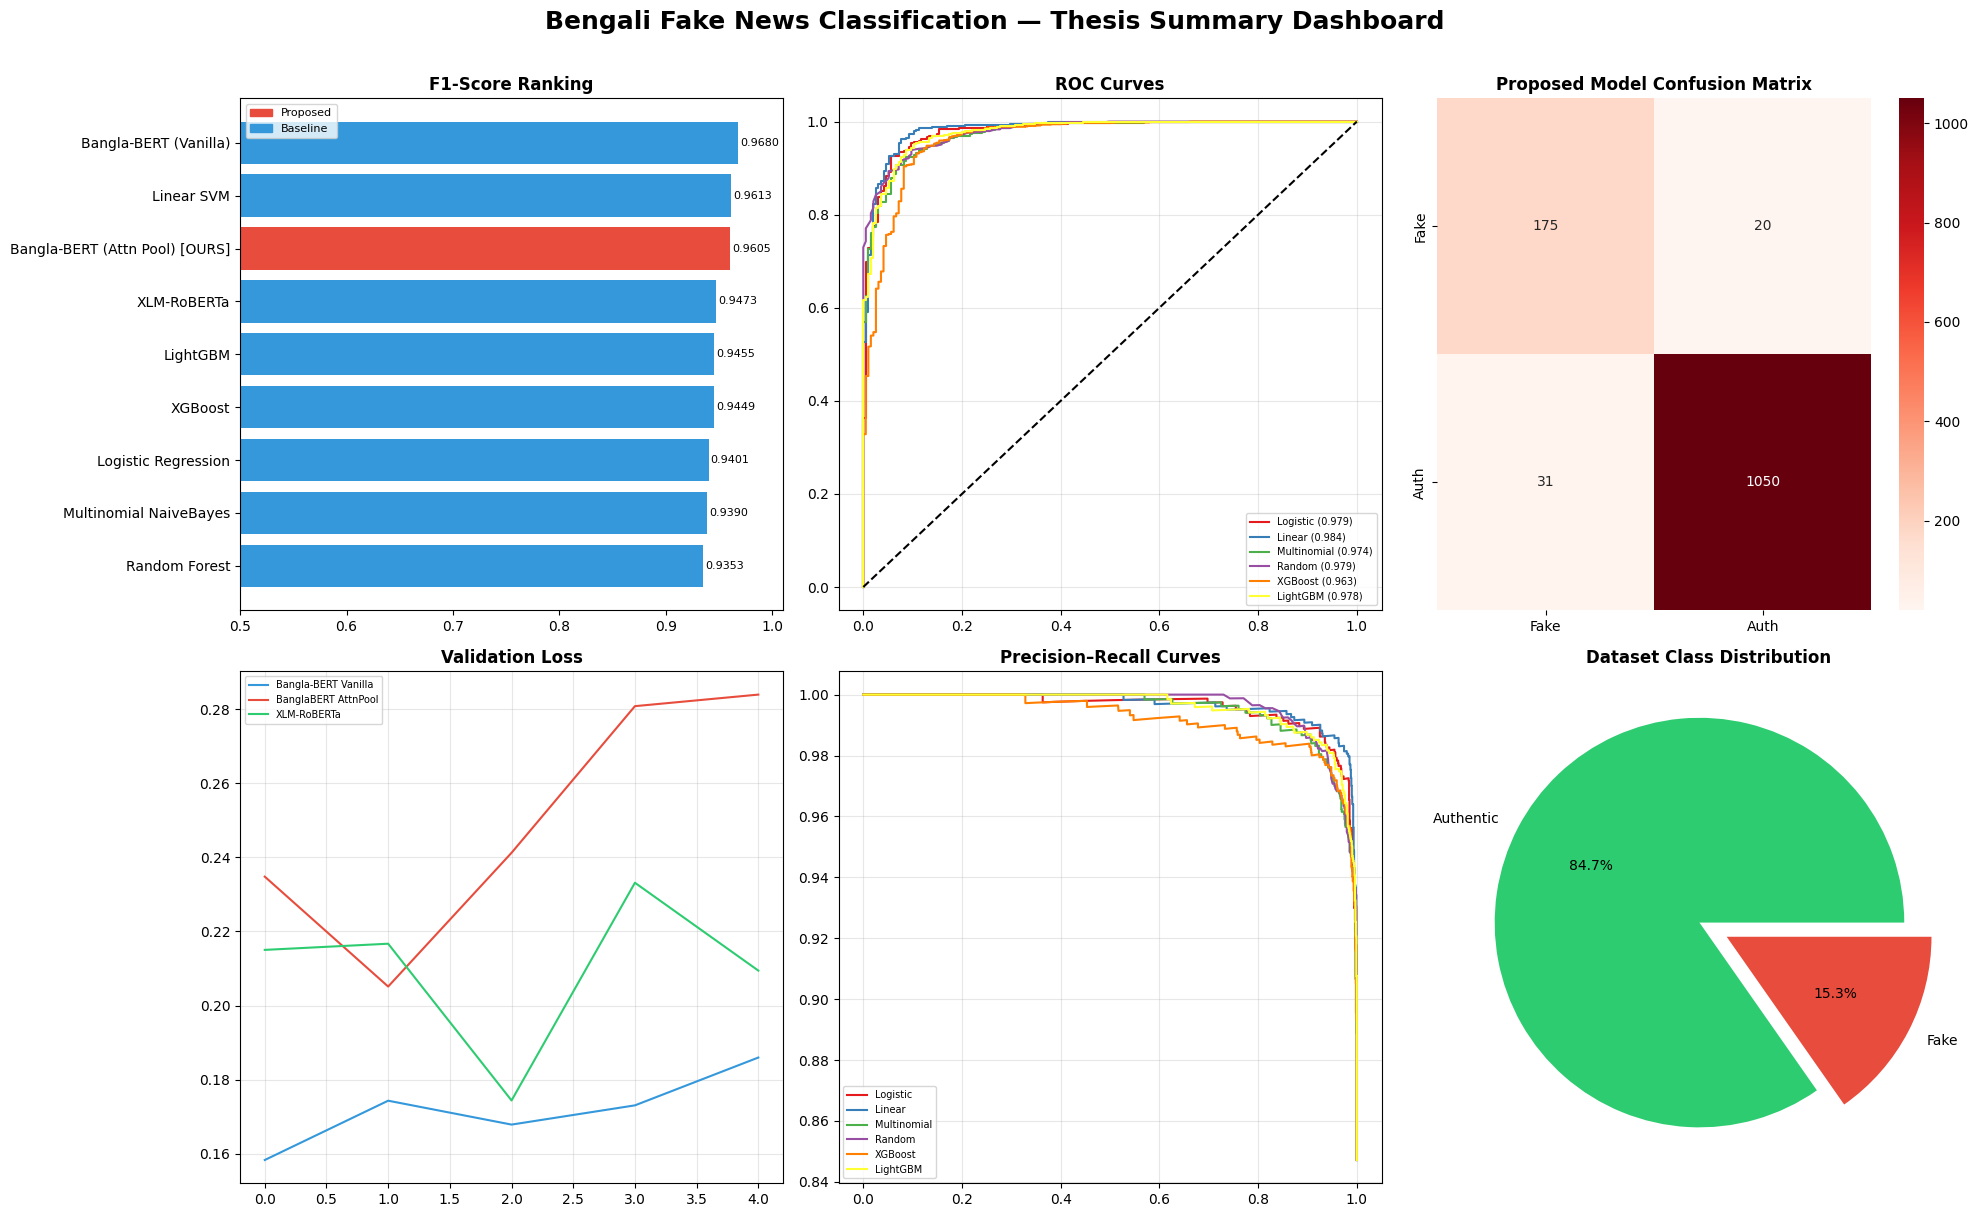

In [33]:
fig = plt.figure(figsize=(20, 12))
fig.suptitle('Bengali Fake News Classification — Thesis Summary Dashboard', 
             fontsize=18, fontweight='bold', y=1.01)

# --- subplot 1: bar chart of F1 scores ---
ax1 = fig.add_subplot(2, 3, 1)
colors_bar = ['#e74c3c' if 'OURS' in m else '#3498db' for m in metrics_df['Model']]
bars = ax1.barh(metrics_df['Model'], metrics_df['F1-Score'], color=colors_bar)
ax1.set_xlim(0.5, 1.01)
ax1.set_title('F1-Score Ranking', fontweight='bold')
ax1.invert_yaxis()
for bar, val in zip(bars, metrics_df['F1-Score']):
    ax1.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=8)
red_patch  = mpatches.Patch(color='#e74c3c', label='Proposed')
blue_patch = mpatches.Patch(color='#3498db', label='Baseline')
ax1.legend(handles=[red_patch, blue_patch], fontsize=8)

# --- subplot 2: ROC ---
ax2 = fig.add_subplot(2, 3, 2)
for i, (name, (labs, proba)) in enumerate(list(all_roc.items())[:6]):
    fpr, tpr, _ = roc_curve(labs, proba)
    ax2.plot(fpr, tpr, color=palette[i], lw=1.5, label=f'{name.split(" ")[0]} ({roc_auc_score(labs, proba):.3f})')
ax2.plot([0,1],[0,1],'k--')
ax2.set_title('ROC Curves', fontweight='bold')
ax2.legend(fontsize=7); ax2.grid(alpha=0.3)

# --- subplot 3: best model confusion matrix ---
ax3 = fig.add_subplot(2, 3, 3)
cm = confusion_matrix(labels_attn, preds_attn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax3,
            xticklabels=['Fake','Auth'], yticklabels=['Fake','Auth'])
ax3.set_title('Proposed Model Confusion Matrix', fontweight='bold')

# --- subplot 4: training loss ---
ax4 = fig.add_subplot(2, 3, 4)
for i, (name, hist) in enumerate(histories.items()):
    ax4.plot(hist['val_loss'], label=name, color=colors_hist[i])
ax4.set_title('Validation Loss', fontweight='bold')
ax4.legend(fontsize=7); ax4.grid(alpha=0.3)

# --- subplot 5: PR curve ---
ax5 = fig.add_subplot(2, 3, 5)
for i, (name, (labs, proba)) in enumerate(list(all_roc.items())[:6]):
    prec, rec, _ = precision_recall_curve(labs, proba)
    ax5.plot(rec, prec, color=palette[i], lw=1.5, label=name.split(' ')[0])
ax5.set_title('Precision–Recall Curves', fontweight='bold')
ax5.legend(fontsize=7); ax5.grid(alpha=0.3)

# --- subplot 6: class distribution ---
ax6 = fig.add_subplot(2, 3, 6)
ax6.pie([len(auth), len(fake)], labels=['Authentic', 'Fake'],
        autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'], explode=(0.05,0.1))
ax6.set_title('Dataset Class Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('thesis_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


# **Lime**

In [34]:
from lime.lime_text import LimeTextExplainer
import torch.nn.functional as F

# 1. Define the class names for the visualization
# Note: In your model, 0 = Fake, 1 = Authentic
class_names = ['Fake (Negative)', 'Authentic (Positive)']

# 2. Define the predictor function for LIME
def lime_predictor(texts):
    model_attn.eval()
    all_probs = []
    
    for text in texts:
        # Tokenize the perturbed text
        inputs = tokenizer_bb(
            text, 
            padding='max_length', 
            truncation=True, 
            max_length=128, 
            return_tensors='pt'
        ).to(DEVICE)
        
        with torch.no_grad():
            logits = model_attn(inputs['input_ids'], inputs['attention_mask'])
            # Convert logits to probabilities
            probs = F.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs[0])
            
    return np.array(all_probs)

# 3. Initialize the LIME Explainer
explainer = LimeTextExplainer(class_names=class_names)

In [35]:
# Select a sample where the model is very confident it is Authentic (Label 1)
pos_idx = test_df_reset[test_df_reset['label'] == 1]['proba_attn'].idxmax()
text_sample_pos = test_df_reset.iloc[pos_idx]['full_text']

print(f"--- Positive Sentiment Example (Authentic) ---")
print(f"Text: {text_sample_pos[:100]}...")

exp_pos = explainer.explain_instance(text_sample_pos, lime_predictor, num_features=10)
exp_pos.show_in_notebook(text=True)

# To save as image or view in non-notebook environments:
# fig = exp_pos.as_pyplot_figure()
# plt.title("LIME: Word Contributions for Positive (Authentic) Sentiment")
# plt.show()

--- Positive Sentiment Example (Authentic) ---
Text: খুবি ছাত্রের ঝুলন্ত লাশ উদ্ধার সহপাঠীদের সন্দেহ চাকরি পাওয়ার হতাশায় আত্মহত্যা [SEP] চাকরি পাওয়ার হতা...


In [36]:
# Find a sample where the probability of being Authentic is closest to 0.5
neutral_idx = (test_df_reset['proba_attn'] - 0.5).abs().idxmin()
text_sample_neu = test_df_reset.iloc[neutral_idx]['full_text']

print(f"--- Neutral Sentiment Example (Uncertain) ---")
print(f"Probability of Authentic: {test_df_reset.iloc[neutral_idx]['proba_attn']:.4f}")

exp_neu = explainer.explain_instance(text_sample_neu, lime_predictor, num_features=10)
exp_neu.show_in_notebook(text=True)

--- Neutral Sentiment Example (Uncertain) ---
Probability of Authentic: 0.4978


In [37]:
# Select a sample where the model is very confident it is Fake (Label 0)
# This corresponds to the lowest 'proba_attn' (probability of being class 1)
neg_idx = test_df_reset[test_df_reset['label'] == 0]['proba_attn'].idxmin()
text_sample_neg = test_df_reset.iloc[neg_idx]['full_text']

print(f"--- Negative Sentiment Example (Fake) ---")
print(f"Text: {text_sample_neg[:100]}...")

exp_neg = explainer.explain_instance(text_sample_neg, lime_predictor, num_features=10)
exp_neg.show_in_notebook(text=True)

--- Negative Sentiment Example (Fake) ---
Text: ২৫ বছরের সাধনায় বোগলের লোম বেণী বরিশালের হেমায়েত [SEP] বোগলের লোম কেটে সম্পূর্ণ অক্ষত অবস্থায় বেণ...
